In [180]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [283]:
n_entries2numeric = {
    # "10k": 10_000,
    "1M": 1_000_000,
    "10M": 10_000_000,
    "100M": 100_000_000
}

df = pd.DataFrame()
for s in range(1,4):
    for i, n_entries in enumerate(["1M", "10M", "100M"]):
        walltime = np.loadtxt(f"../results/scenario{s}/{n_entries}.csv", delimiter=",", skiprows=1, usecols=2)
        row = {"scenario": [s], "n_entries": [n_entries2numeric[n_entries]], "walltime_mean": [walltime.mean() * 1e-6], "walltime_std": [walltime.std()]}
        df = pd.concat([df, pd.DataFrame(row)])
        
    
    # scenario["scenario"] = np.full(scenario["10M"].shape, s)
    # df_scenario = pd.DataFrame(scenario)
    # df = pd.concat([df, df_scenario])
df.reset_index(drop=True, inplace=True)
df = df.pivot(index="n_entries", columns="scenario")
df

walltime_mean                       walltime_std                \
scenario              1         2         3              1             2   
n_entries                                                                  
1000000        0.067287  0.076146  0.079863     599.056391   1069.897677   
10000000       0.647077  0.773720  0.740330   26713.104877  26408.307438   
100000000      5.937040  6.238413  6.887879  203726.765159  42247.367535   

                         
scenario              3  
n_entries                
1000000     1250.519828  
10000000    4937.740155  
100000000  32496.785703

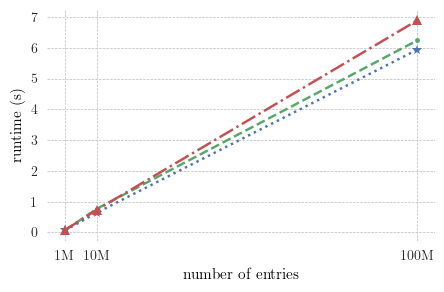

In [298]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.facecolor": "#FFFFFF",
    "axes.grid": True,
    "axes.grid.which": "major",
    "axes.grid.axis": "both",
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "grid.color": "#BBBBBB",
    "grid.linestyle": "--",
    "grid.linewidth": .5,
    "figure.frameon": True
})

fig, ax = plt.subplots(figsize=(5,3))
# ax.set_xscale("log")
ax.set_xticks(df.index, labels=n_entries2numeric.keys())
ax.set_xlabel("number of entries")
ax.set_ylabel("runtime (s)")

linestyles = [":", "--", "-."]
markers = ["*", ".", "^"]
for i, s in enumerate(df.walltime_mean.columns):
    ax.plot(df.walltime_mean[s],
            linestyle=linestyles[i], 
            marker=markers[i]
           )